## Почему выбран этот датасет:
**Актуальность**: Диабет — одна из главных проблем здравоохранения. \
**Качество**: Это очищенная версия огромного государственного опроса, что гарантирует реалистичные зависимости. \
**Сложность**: Датасет имеет сильный дисбаланс классов (особенно преддиабет), что делает задачу интересной с точки зрения подбора метрик и настройки моделей. \
**Разнообразие признаков**: Сочетает физические показатели, вредные привычки и социально-экономические факторы.

## Описание датасета
Объём: 253 680 строк и 22 столбца. \
Целевая переменная (Diabetes_012): \
0: нет диабета. \
1: преддиабет. \
2: диабет.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('..\\data\\raw\\diabetes-health-indicators-dataset\\diabetes_012_health_indicators_BRFSS2015.csv')

print(f"Форма данных: {df.shape}")
print(f"Пропущенные значения: {df.isnull().sum().sum()}")
print(f"Дубликаты: {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.2f}%)")

Форма данных: (253680, 22)
Пропущенные значения: 0
Дубликаты: 23899 (9.42%)


In [3]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
multi_cols = [col for col in df.columns if 2 < df[col].nunique() < 15]

for col in binary_cols + multi_cols:
    df[col] = df[col].astype(np.int8)

df['BMI'] = df['BMI'].astype(np.float32)

Распределение классов:
Diabetes_012
0    84.241170
2    13.933302
1     1.825528
Name: proportion, dtype: float64


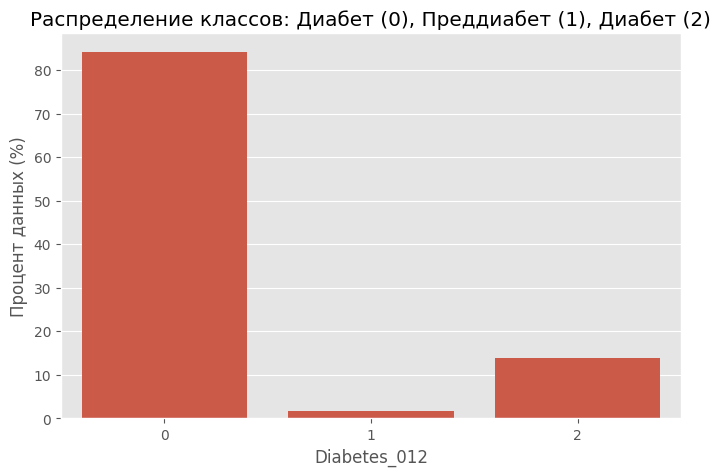

In [4]:
target_counts = df['Diabetes_012'].value_counts(normalize=True) * 100
print(f"Распределение классов:\n{target_counts}")

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Распределение классов: Диабет (0), Преддиабет (1), Диабет (2)')
plt.ylabel('Процент данных (%)')
plt.show()

### Физиологические показатели: ИМТ, Давление, Холестерин

Эти факторы считаются "золотым стандартом" в медицине. Проверим их значимость в наших данных.

C:\Users\user\AppData\Local\Temp\ipykernel_26764\1335675218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y='BMI', data=df, ax=axes[0], palette='Set2')


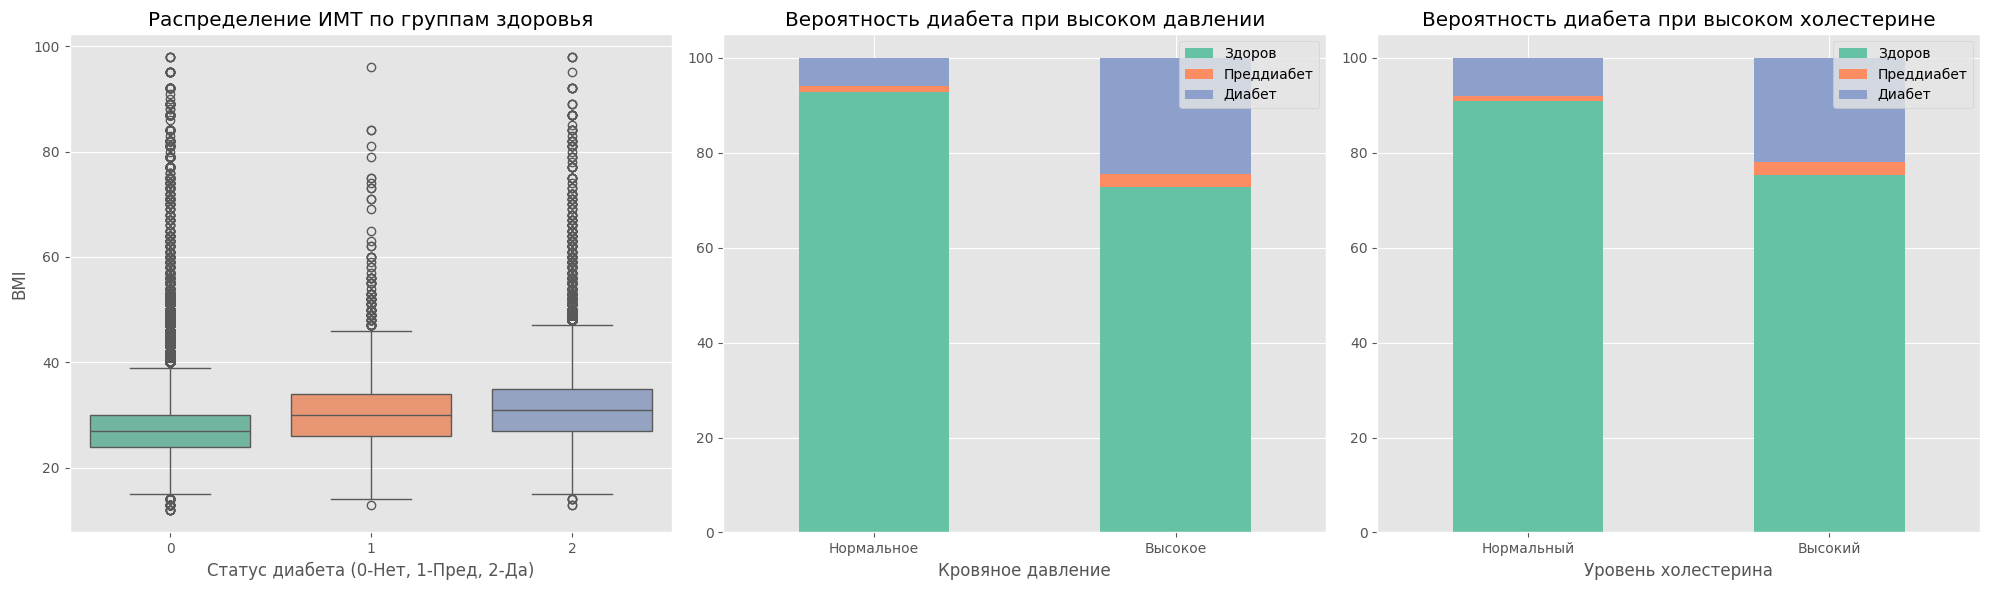

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(x='Diabetes_012', y='BMI', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Распределение ИМТ по группам здоровья')
axes[0].set_xlabel('Статус диабета (0-Нет, 1-Пред, 2-Да)')

prob_bp = df.groupby('HighBP')['Diabetes_012'].value_counts(normalize=True).unstack() * 100
prob_bp.plot(kind='bar', stacked=True, ax=axes[1], color=['#66c2a5', '#fc8d62', '#8da0cb'])
axes[1].set_title('Вероятность диабета при высоком давлении')
axes[1].set_xticklabels(['Нормальное', 'Высокое'], rotation=0) # Человекочитаемые подписи
axes[1].set_xlabel('Кровяное давление')
axes[1].legend(['Здоров', 'Преддиабет', 'Диабет'], loc='upper right')

prob_chol = df.groupby('HighChol')['Diabetes_012'].value_counts(normalize=True).unstack() * 100
prob_chol.plot(kind='bar', stacked=True, ax=axes[2], color=['#66c2a5', '#fc8d62', '#8da0cb'])
axes[2].set_title('Вероятность диабета при высоком холестерине')
axes[2].set_xticklabels(['Нормальный', 'Высокий'], rotation=0) # Человекочитаемые подписи
axes[2].set_xlabel('Уровень холестерина')
axes[2].legend(['Здоров', 'Преддиабет', 'Диабет'], loc='upper right')

plt.tight_layout()
plt.show()

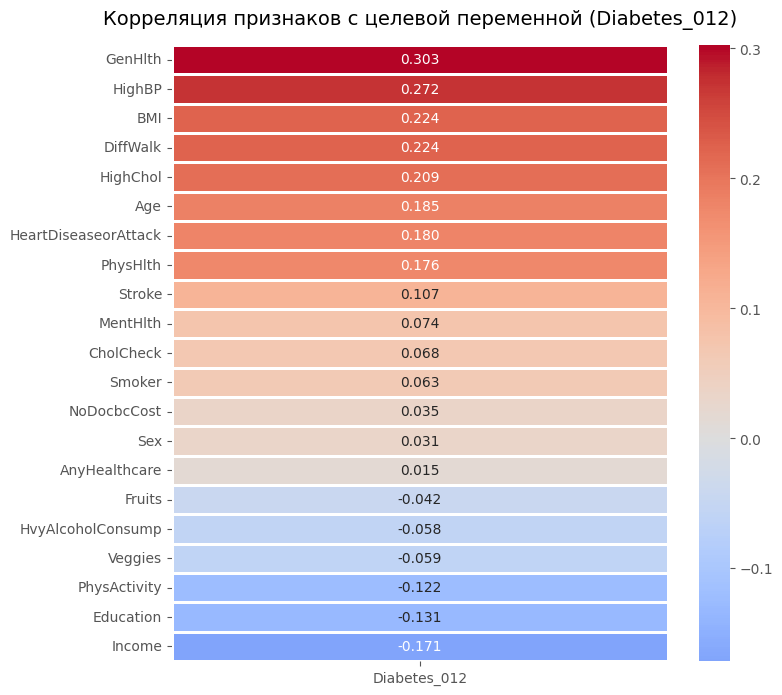

In [8]:
plt.figure(figsize=(8, 8))

target_corr = df.corr()[['Diabetes_012']].sort_values(by='Diabetes_012', ascending=False)

target_corr = target_corr.drop('Diabetes_012')

sns.heatmap(target_corr, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            center=0, 
            linewidths=1, 
            linecolor='white')

plt.title('Корреляция признаков с целевой переменной (Diabetes_012)', fontsize=14, pad=15)
plt.show()

In [9]:
df.to_csv('..\\data\\processed\\diabetes_012_health_indicators_BRFSS2015_processed.csv', index=False)